In [4]:
# Transformer_Map_Interp/datasets/make_dt2_splits.py
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import rasterio
print(os.getcwd())
sys.path.append(os.path.abspath("../"))  # project root
#os.chdir("../")
# print(os.getcwd())
from Transformer_Map_Interp.datasets.dt2_data import DT2Dataset

c:\Users\ORITMI\OneDrive - Rafael\Project B - Alon Asaf Orit\kcn-torch-master\Project-B-Technion\kcn-torch-master\Transformer_Map_Interp


In [57]:
# ----------------------------
# CONFIG
# ----------------------------

OUT_DIR    = "..\Transformer_Map_Interp\datasets"   # where to put train/val/test tiffs
TRAIN_TIF  = os.path.join(OUT_DIR, "train_blobs_new.tiff")
VAL_TIF    = os.path.join(OUT_DIR, "val_blobs_new.tiff")
TEST_TIF   = os.path.join(OUT_DIR, "test_blobs_new.tiff")

FIG_DIR    = "./Transformer_Map_Interp/figures"

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
SEA_THRESHOLD_M = 0.0      # treat y <= 5 m as "sea"
N_CLUSTERS = 40            # number of spatial blobs
SEED       = 5

<>:5: SyntaxWarning: invalid escape sequence '\T'
<>:5: SyntaxWarning: invalid escape sequence '\T'
C:\Users\ORITMI\AppData\Local\Temp\1\ipykernel_3016\3688444740.py:5: SyntaxWarning: invalid escape sequence '\T'
  OUT_DIR    = "..\Transformer_Map_Interp\datasets"   # where to put train/val/test tiffs


In [58]:
# ----------------------------
# 1. Load DT2 + remove sea
# ----------------------------
print(f"Loading DT2 from {OUT_DIR}")
trainset = DT2Dataset(TRAIN_TIF, include_elevation_in_features=False)
validset = DT2Dataset(VAL_TIF, include_elevation_in_features=False)
testset = DT2Dataset(TEST_TIF, include_elevation_in_features=False)


Loading DT2 from ..\Transformer_Map_Interp\datasets
I am reading!
I am reading!
I am reading!


tensor([  3.,   3.,   4.,  ..., 725., 728., 730.])


C:\Users\ORITMI\AppData\Local\Temp\1\ipykernel_3016\1362846904.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\ORITMI\AppData\Local\Temp\1\ipykernel_3016\1362846904.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 800x600 with 0 Axes>

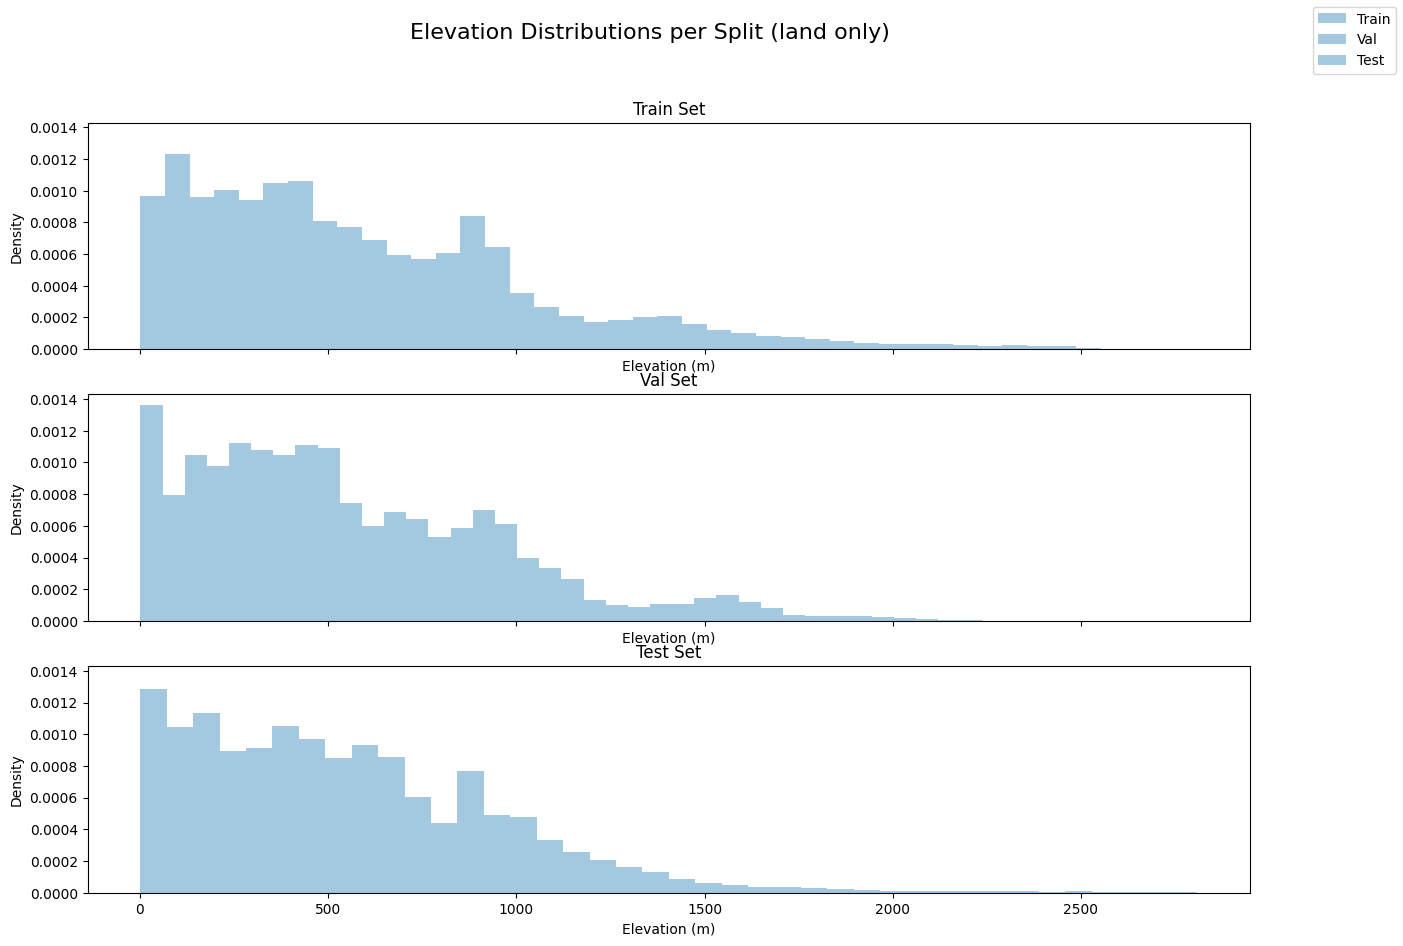

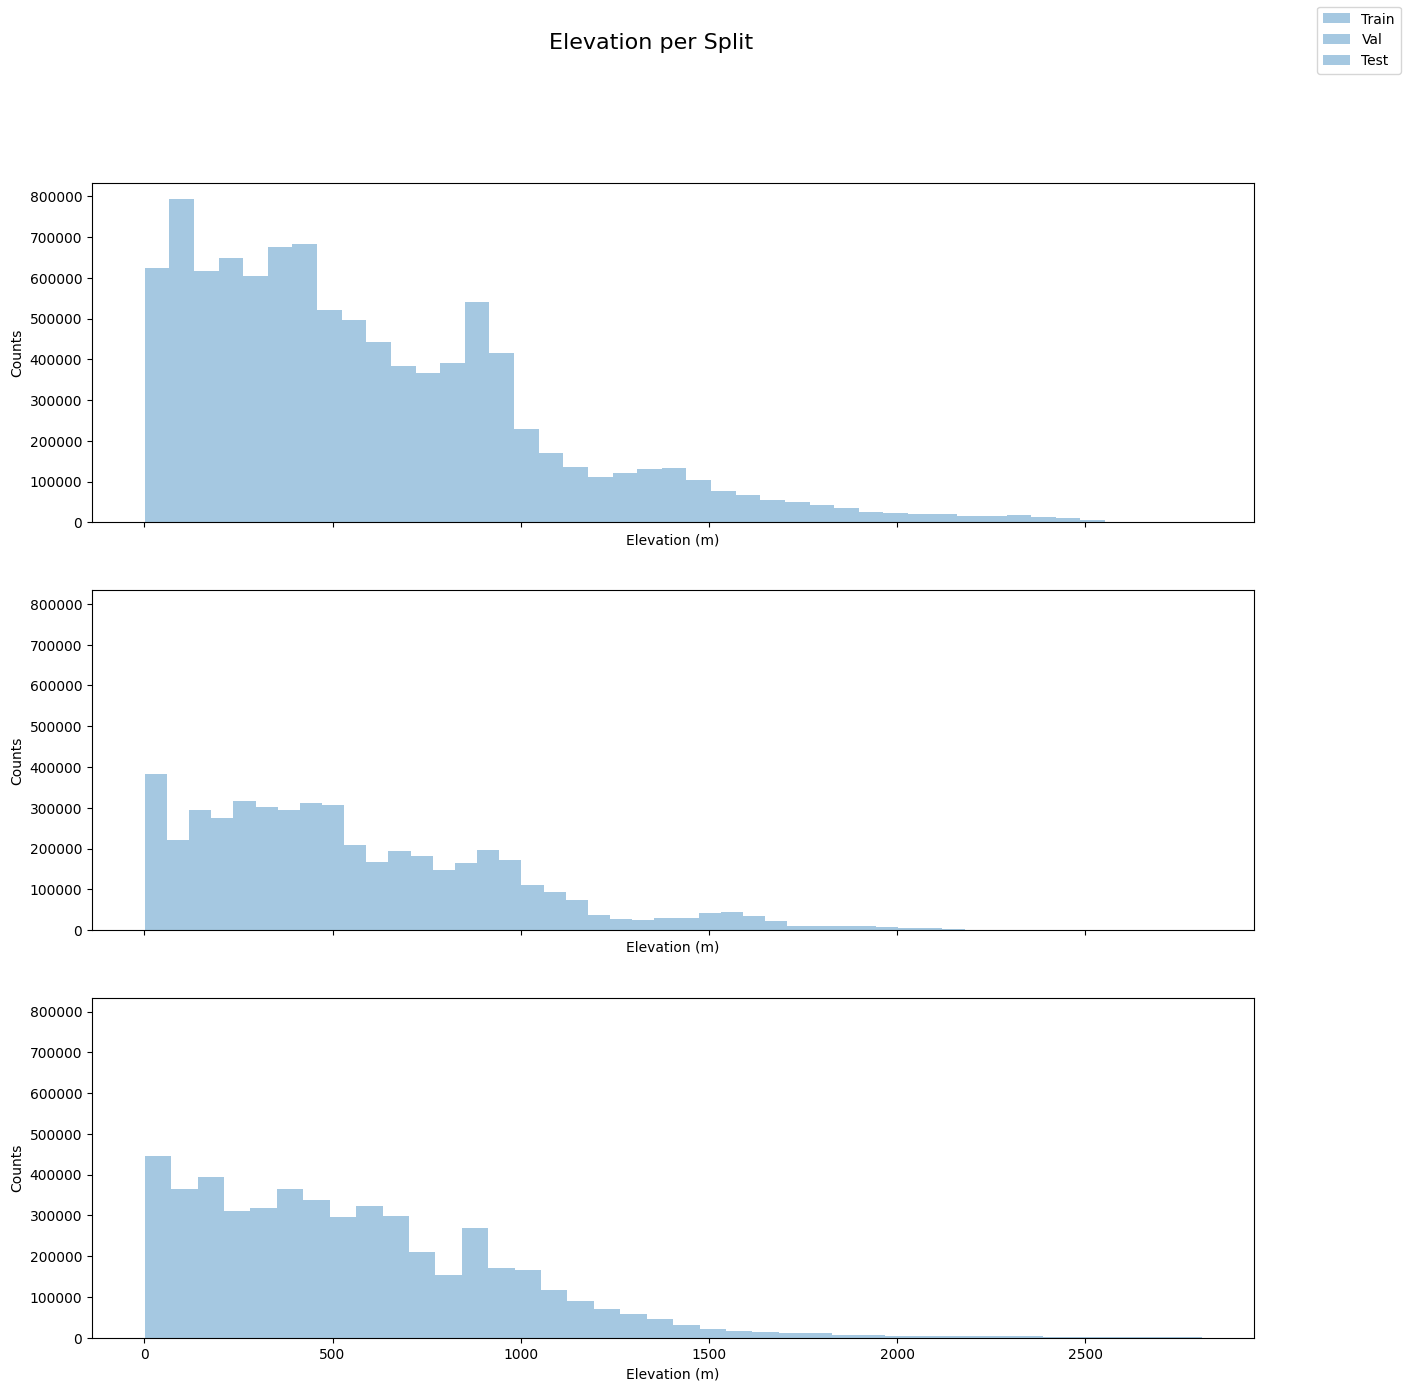

In [59]:
bins = 40
plt.figure(figsize=(8, 6))
ind_train = (trainset.y > 0)
ind_test = (testset.y > 0)
ind_val = (validset.y > 0)
print(trainset.y[ind_train])

# 1. Create a figure with 3 subplots in a row (1 row, 3 columns)
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, sharey=True)
fig.suptitle("Elevation Distributions per Split (land only)", fontsize=16)

# 3. Set the Y-axis label only on the leftmost subplot
axes[0].hist(trainset.y[ind_train], bins=bins, density=True, alpha=0.4, label="Train")
axes[0].set_ylabel("Density")
axes[0].set_xlabel("Elevation (m)")
axes[0].set_title("Train Set")

axes[1].hist(validset.y[ind_val],   bins=bins, density=True, alpha=0.4, label="Val")
axes[1].set_ylabel("Density")
axes[1].set_xlabel("Elevation (m)")
axes[1].set_title("Val Set")

axes[2].hist(testset.y[ind_test],  bins=bins, density=True, alpha=0.4, label="Test")
axes[2].set_ylabel("Density")
axes[2].set_xlabel("Elevation (m)")
axes[2].set_title("Test Set")
fig.legend()
fig.show()

# 1. Create a figure with 3 subplots in a row (1 row, 3 columns)
fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True, sharey=True)
fig.suptitle("Elevation per Split ", fontsize=16)

# 3. Set the Y-axis label only on the leftmost subplot
axes[0].hist(trainset.y[ind_train], bins=bins, alpha=0.4, label="Train")
axes[0].set_ylabel("Counts")
axes[0].set_xlabel("Elevation (m)")

axes[1].hist(validset.y[ind_val],   bins=bins,alpha=0.4, label="Val")
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Elevation (m)")

axes[2].hist(testset.y[ind_test],  bins=bins, alpha=0.4, label="Test")
axes[2].set_ylabel("Counts")
axes[2].set_xlabel("Elevation (m)")
fig.legend()
fig.show()


In [60]:
# Train
import torch
print(trainset.y[ind_train].shape)
mean = torch.mean(trainset.y[ind_train])
std = torch.std(trainset.y[ind_train])
max = torch.max(trainset.y[ind_train])
min = torch.min(trainset.y[ind_train])
print(f"Train set: elev_mean={mean}, elev_std={std}, elev_max={max}, elev_min={min}")

torch.Size([9842996])
Train set: elev_mean=600.0753784179688, elev_std=464.02618408203125, elev_max=2618.0, elev_min=1.0


In [61]:
# Valid
import torch
print(validset.y[ind_val].shape)
mean = torch.mean(validset.y[ind_val])
std = torch.std(validset.y[ind_val])
max = torch.max(validset.y[ind_val])
min = torch.min(validset.y[ind_val])
print(f"Valid set: elev_mean={mean}, elev_std={std}, elev_max={max}, elev_min={min}")

torch.Size([4765770])
Valid set: elev_mean=554.7459106445312, elev_std=411.7688293457031, elev_max=2356.0, elev_min=1.0


In [62]:
# Test
import torch
print(testset.y[ind_test].shape)
mean = torch.mean(testset.y[ind_test])
std = torch.std(testset.y[ind_test])
max = torch.max(testset.y[ind_test])
min = torch.min(testset.y[ind_test])
print(f"Test set: elev_mean={mean}, elev_std={std}, elev_max={max}, elev_min={min}")

torch.Size([4951257])
Test set: elev_mean=546.8013305664062, elev_std=407.833251953125, elev_max=2809.0, elev_min=1.0
